# Dia 18/09 — M4: Qualidade dos dados

**Capacitação PneumoVision** · IFPE · INPaR · Financiamento FACEPE

Vamos medir a **qualidade** dos keypoints do seu vídeo e decidir se está bom o suficiente
(meta do projeto: detecção válida em **≥ 90%** dos quadros). Cada parâmetro comentado.

## 1. Preparação e dados

In [2]:
import json
import matplotlib.pyplot as plt

# Ler o JSON real gerado na M3
with open("keypoints.json", encoding="utf-8") as f:
    kp = json.load(f)

frames = kp["frames"]

print("quadros:", len(frames))

quadros: 558


## 2. Taxa de detecção (mãos e pose)

In [3]:
total = len(frames)                                   # total de quadros
com_mao = sum(1 for f in frames if f["hands"])        # quadros com mão
com_pose = sum(1 for f in frames if f["pose"])        # quadros com pose
taxa_mao = com_mao / total                            # fração 0..1
taxa_pose = com_pose / total
print(f"mãos: {com_mao}/{total} = {100*taxa_mao:.1f}%")
print(f"pose: {com_pose}/{total} = {100*taxa_pose:.1f}%")

mãos: 539/558 = 96.6%
pose: 558/558 = 100.0%


## 3. Linha do tempo da detecção

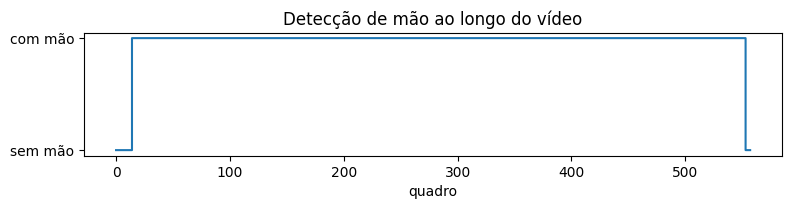

In [4]:
# 1 quando há mão no quadro, 0 quando não há
linha = [1 if f["hands"] else 0 for f in frames]      # lista de 0/1
plt.figure(figsize=(9, 1.6))                          # figura larga e baixa
plt.plot(linha, drawstyle="steps-post")               # degraus: mostra on/off
plt.yticks([0, 1], ["sem mão", "com mão"])            # rótulos do eixo y
plt.xlabel("quadro"); plt.title("Detecção de mão ao longo do vídeo"); plt.show()

## 4. Maior sequência sem detecção

In [6]:
maior = atual = 0                          # maior gap encontrado / gap atual
for v in linha:                            # percorre a linha do tempo
    if v == 0:                             # quadro sem mão
        atual += 1                         # aumenta o gap atual
        maior = max(maior, atual)          # atualiza o maior gap
    else:                                  # quadro com mão
        atual = 0                          # zera o gap atual
print("maior sequência sem detecção:", maior, "quadros")

maior sequência sem detecção: 14 quadros


## 5. Veredito de qualidade (meta ≥ 90%)

In [7]:
META = 0.90                                # meta do projeto (M2)
if taxa_mao >= META:                        # atingiu a meta?
    print(f"✔ OK: detecção de mãos {100*taxa_mao:.1f}% (>= 90%). Dados prontos para modelar.")
else:
    print(f"✗ ABAIXO da meta: {100*taxa_mao:.1f}% (< 90%). Sugestões para regravar:")
    print("  - Melhore a iluminação (luz de frente, sem contraluz).")
    print("  - Mantenha as mãos totalmente no enquadramento.")
    print("  - Evite movimento muito rápido e fundo confuso.")
    print("  - Aumente a resolução/estabilidade (apoie o celular).")

✔ OK: detecção de mãos 96.6% (>= 90%). Dados prontos para modelar.


## 6. Sua entrega (M4)

Rode esta análise sobre o **seu** `keypoints.json` (do M3). Entregue um **relatório de meia
página** com: a taxa de detecção obtida, o que mudou após regravar (se precisou) e uma
observação sobre a qualidade dos keypoints.

**Critério de aceite:** relata a taxa final; se abaixo de 90%, mostra a tentativa de melhoria.
